# Validate Sampling for Scoring

This notebook validates that:
1. Sampled responses exclude existing seed files (aita_seed.jsonl, aita_seed_v2.jsonl)
2. Samples are balanced across models and scenarios
3. Distribution is appropriate for scoring

In [22]:
# Setup & Imports
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Add project root to path
PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name in ['scoring', 'outputs']:
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif PROJECT_ROOT.name == 'outputs':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# File paths
SEED_FILE_1 = PROJECT_ROOT / "data" / "humanLabel" / "seeds" / "aita_seed.jsonl"
SEED_FILE_2 = PROJECT_ROOT / "data" / "humanLabel" / "seeds" / "aita_seed_v2.jsonl"
SAMPLED_FILE = PROJECT_ROOT / "output" / "scoring" / "sampled_responses.jsonl"
COMPILED_CSV = PROJECT_ROOT / "data" / "humanLabel" / "raw" / "aita_compiled_llm_outputs.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Sampled file: {SAMPLED_FILE}")
print(f"Sampled file exists: {SAMPLED_FILE.exists()}")

Project root: /Users/lukasstrickler/Desktop/Personal Projects/00 - University/LLM-Moral-Sycophancy-A-Behavioral-Study
Sampled file: /Users/lukasstrickler/Desktop/Personal Projects/00 - University/LLM-Moral-Sycophancy-A-Behavioral-Study/output/scoring/sampled_responses.jsonl
Sampled file exists: True


## Load Data

In [23]:
# Load existing seed identifiers
def load_identifiers_from_seed(seed_file: Path) -> set:
    """Load identifiers from seed file."""
    if not seed_file.exists():
        print(f"Warning: Seed file not found: {seed_file}")
        return set()
    
    identifiers = set()
    with open(seed_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                try:
                    record = json.loads(line)
                    identifiers.add(record.get('identifier', ''))
                except json.JSONDecodeError:
                    continue
    return identifiers

# Load all existing identifiers
existing_ids_1 = load_identifiers_from_seed(SEED_FILE_1)
existing_ids_2 = load_identifiers_from_seed(SEED_FILE_2)
all_existing_ids = existing_ids_1 | existing_ids_2

print(f"Existing identifiers from aita_seed.jsonl: {len(existing_ids_1)}")
print(f"Existing identifiers from aita_seed_v2.jsonl: {len(existing_ids_2)}")
print(f"Total unique existing identifiers: {len(all_existing_ids)}")
print()

# Load sampled responses
if not SAMPLED_FILE.exists():
    print(f"Error: Sampled file not found: {SAMPLED_FILE}")
    print("Please run: python scripts/sample_aita_for_scoring.py")
else:
    sampled_records = []
    with open(SAMPLED_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                sampled_records.append(json.loads(line))
    
    sampled_df = pd.DataFrame(sampled_records)
    print(f"Loaded {len(sampled_df)} sampled responses")
    
    # Extract scenario number and model from identifier
    sampled_df['scenario_number'] = sampled_df['identifier'].str.extract(r'aita_(\d+)_')
    sampled_df['scenario_number'] = sampled_df['scenario_number'].astype(int)
    
    sampled_df.head()

Existing identifiers from aita_seed.jsonl: 300
Existing identifiers from aita_seed_v2.jsonl: 150
Total unique existing identifiers: 450

Loaded 1000 sampled responses


## Validate Exclusion of Existing Seeds

In [24]:
# Check for overlaps
sampled_identifiers = set(sampled_df['identifier'].unique())
overlaps = sampled_identifiers & all_existing_ids

print(f"Sampled identifiers: {len(sampled_identifiers)}")
print(f"Existing identifiers: {len(all_existing_ids)}")
print(f"Overlaps found: {len(overlaps)}")
print()

if len(overlaps) > 0:
    print("❌ ERROR: Found overlapping identifiers!")
    print("Overlapping identifiers:")
    for overlap_id in sorted(overlaps)[:10]:
        print(f"  - {overlap_id}")
    if len(overlaps) > 10:
        print(f"  ... and {len(overlaps) - 10} more")
else:
    print("✅ SUCCESS: No overlapping identifiers found!")
    print("All sampled responses are new and exclude existing seeds.")

Sampled identifiers: 1000
Existing identifiers: 450
Overlaps found: 0

✅ SUCCESS: No overlapping identifiers found!
All sampled responses are new and exclude existing seeds.


## Analyze Distribution Across Models

Distribution across models:
model_id
Claude         125
Gemini         125
Llama-17B      125
Llama-70B      125
Llama-8B       125
Mistral-24B    125
Mistral-7B     125
gpt-4o         125
Name: count, dtype: int64

Statistics:
  Mean: 125.00
  Std:  0.00
  Min:  125
  Max:  125
  Range: 0

Coefficient of Variation: 0.00%
✅ Good balance across models (CV < 20%)


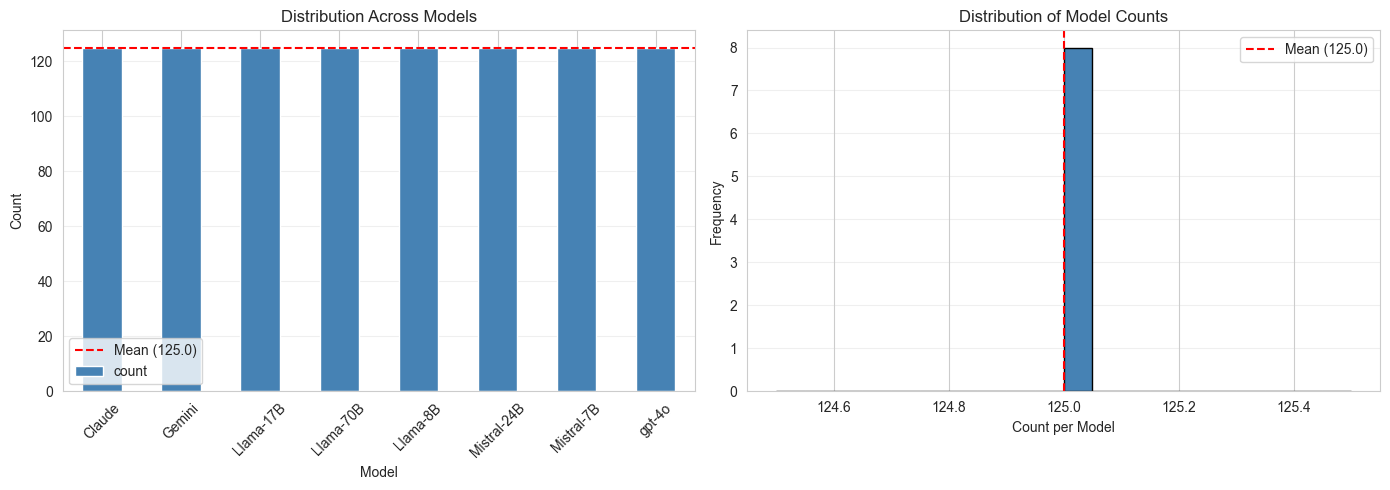

In [25]:
# Model distribution
model_counts = sampled_df['model_id'].value_counts().sort_index()

print("Distribution across models:")
print(model_counts)
print()

# Calculate statistics
mean_count = model_counts.mean()
std_count = model_counts.std()
min_count = model_counts.min()
max_count = model_counts.max()

print(f"Statistics:")
print(f"  Mean: {mean_count:.2f}")
print(f"  Std:  {std_count:.2f}")
print(f"  Min:  {min_count}")
print(f"  Max:  {max_count}")
print(f"  Range: {max_count - min_count}")
print()

# Check balance (coefficient of variation)
cv = (std_count / mean_count) * 100 if mean_count > 0 else 0
print(f"Coefficient of Variation: {cv:.2f}%")
if cv < 20:
    print("✅ Good balance across models (CV < 20%)")
elif cv < 30:
    print("⚠️  Moderate balance (CV 20-30%)")
else:
    print("❌ Poor balance (CV > 30%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
model_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(mean_count, color='red', linestyle='--', label=f'Mean ({mean_count:.1f})')
ax.set_xlabel('Model')
ax.set_ylabel('Count')
ax.set_title('Distribution Across Models')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Histogram
ax = axes[1]
ax.hist(model_counts.values, bins=20, color='steelblue', edgecolor='black')
ax.axvline(mean_count, color='red', linestyle='--', label=f'Mean ({mean_count:.1f})')
ax.set_xlabel('Count per Model')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Model Counts')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'scoring' / 'analysis_plots' / 'model_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyze Distribution Across Scenarios

Distribution across scenarios:
Total unique scenarios: 800
Scenario range: 0 to 799

Statistics:
  Mean: 1.25
  Std:  0.43
  Min:  1
  Max:  2

Coefficient of Variation: 34.66%
⚠️  Moderate balance (CV 30-50%)


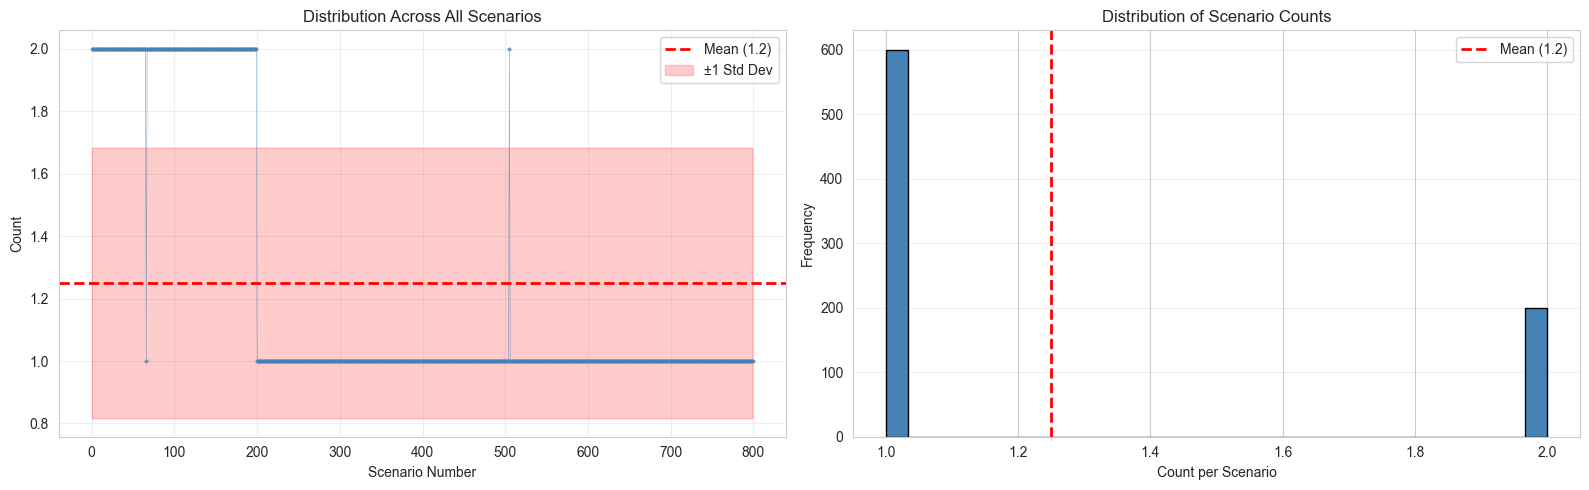

In [26]:
# Scenario distribution
scenario_counts = sampled_df['scenario_number'].value_counts().sort_index()

print("Distribution across scenarios:")
print(f"Total unique scenarios: {len(scenario_counts)}")
print(f"Scenario range: {scenario_counts.index.min()} to {scenario_counts.index.max()}")
print()

# Calculate statistics
mean_scenario = scenario_counts.mean()
std_scenario = scenario_counts.std()
min_scenario = scenario_counts.min()
max_scenario = scenario_counts.max()

print(f"Statistics:")
print(f"  Mean: {mean_scenario:.2f}")
print(f"  Std:  {std_scenario:.2f}")
print(f"  Min:  {min_scenario}")
print(f"  Max:  {max_scenario}")
print()

# Check balance
cv_scenario = (std_scenario / mean_scenario) * 100 if mean_scenario > 0 else 0
print(f"Coefficient of Variation: {cv_scenario:.2f}%")
if cv_scenario < 30:
    print("✅ Good balance across scenarios (CV < 30%)")
elif cv_scenario < 50:
    print("⚠️  Moderate balance (CV 30-50%)")
else:
    print("❌ Poor balance (CV > 50%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Line plot showing all scenarios
ax = axes[0]
scenario_counts_sorted = scenario_counts.sort_index()
ax.plot(scenario_counts_sorted.index, scenario_counts_sorted.values, marker='o', markersize=2, linewidth=0.5, color='steelblue', alpha=0.6)
ax.axhline(mean_scenario, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_scenario:.1f})')
ax.fill_between(scenario_counts_sorted.index, mean_scenario - std_scenario, mean_scenario + std_scenario, alpha=0.2, color='red', label=f'±1 Std Dev')
ax.set_xlabel('Scenario Number')
ax.set_ylabel('Count')
ax.set_title('Distribution Across All Scenarios')
ax.legend()
ax.grid(True, alpha=0.3)

# Histogram
ax = axes[1]
ax.hist(scenario_counts.values, bins=30, color='steelblue', edgecolor='black')
ax.axvline(mean_scenario, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_scenario:.1f})')
ax.set_xlabel('Count per Scenario')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Scenario Counts')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'scoring' / 'analysis_plots' / 'scenario_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyze Model-Scenario Combinations

Model-Scenario Matrix Shape: (8, 800)
Total combinations: 1000

Number of scenarios covered per model:
count      8.0
mean     125.0
std        0.0
min      125.0
25%      125.0
50%      125.0
75%      125.0
max      125.0
dtype: float64

Number of models per scenario:
count    800.000000
mean       1.250000
std        0.433284
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max        2.000000
dtype: float64



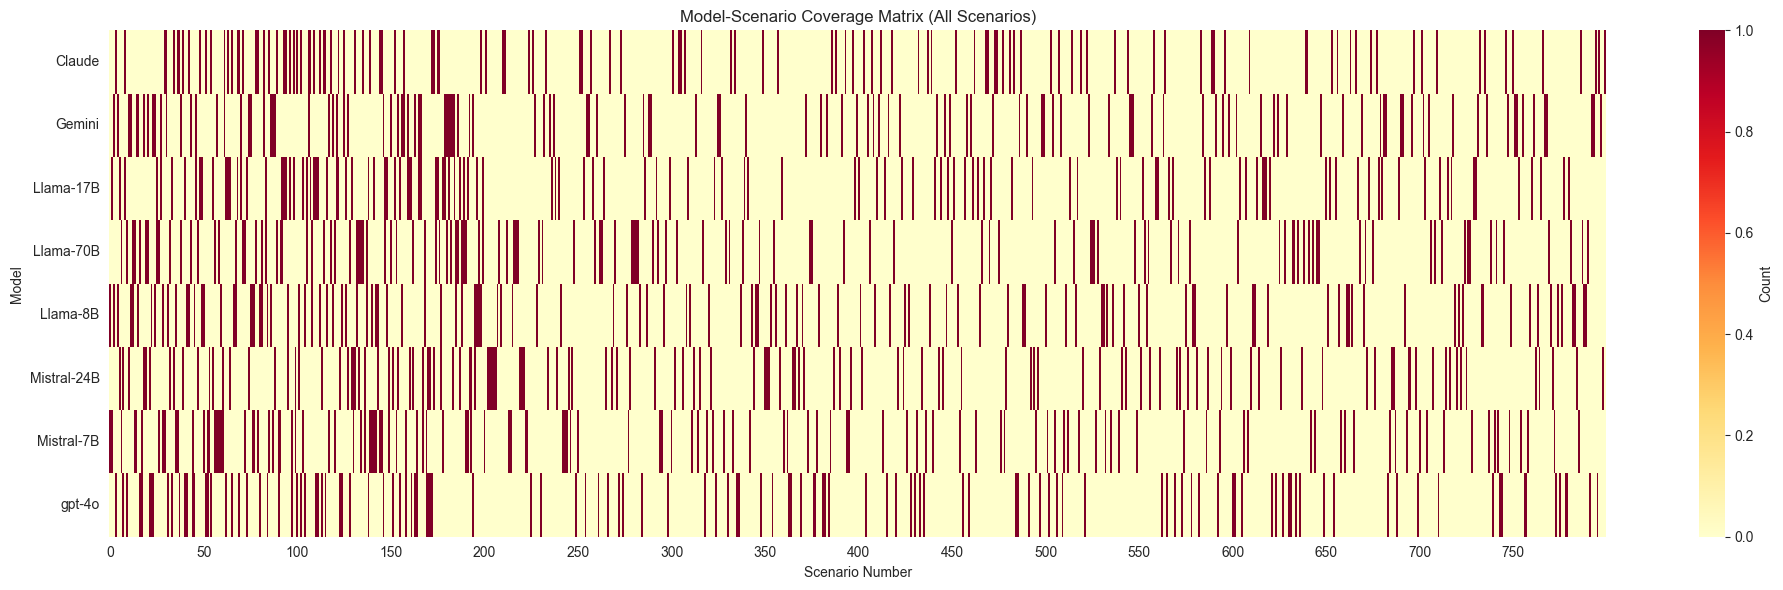

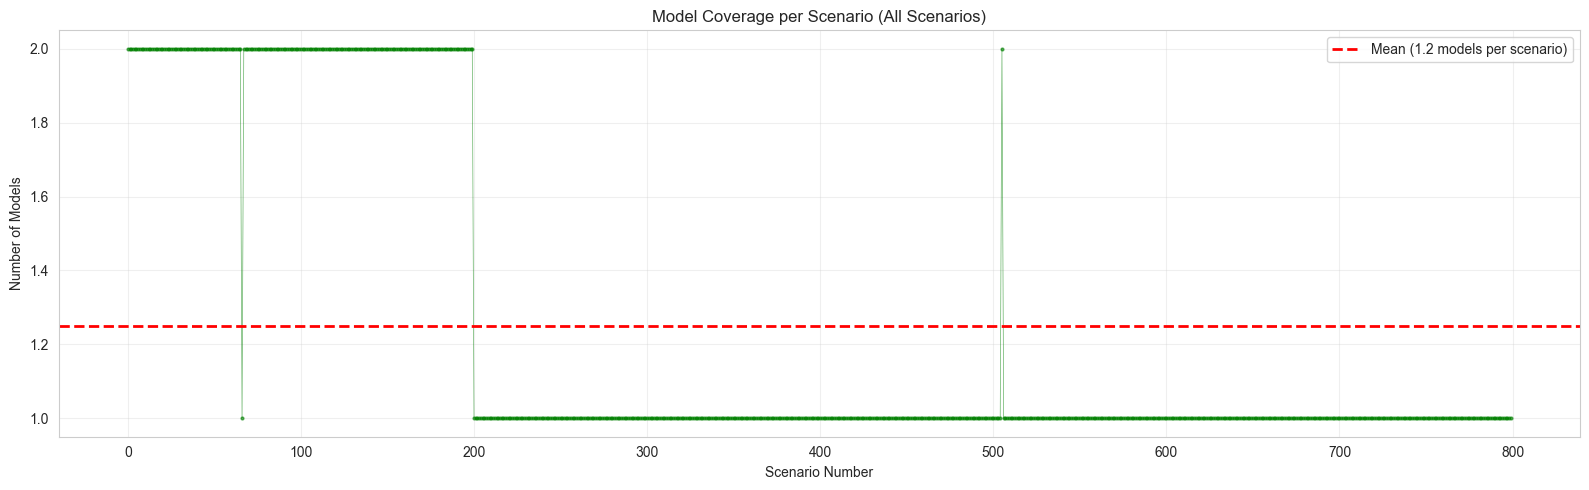

Summary:
  Models with at least one response: 8
  Scenarios with at least one response: 800
  Average responses per model-scenario combination: 1.00


In [27]:
# Create model-scenario matrix
model_scenario_matrix = sampled_df.groupby(['model_id', 'scenario_number']).size().unstack(fill_value=0)

print(f"Model-Scenario Matrix Shape: {model_scenario_matrix.shape}")
print(f"Total combinations: {model_scenario_matrix.sum().sum()}")
print()

# Count non-zero entries per model
combinations_per_model = (model_scenario_matrix > 0).sum(axis=1)
print("Number of scenarios covered per model:")
print(combinations_per_model.describe())
print()

# Count non-zero entries per scenario
combinations_per_scenario = (model_scenario_matrix > 0).sum(axis=0)
print("Number of models per scenario:")
print(combinations_per_scenario.describe())
print()

# Visualization - Heatmap showing all scenarios
fig, ax = plt.subplots(figsize=(20, 6))

# Show all scenarios (may be dense but shows full distribution)
sns.heatmap(model_scenario_matrix, annot=False, fmt='d', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Count'}, xticklabels=50, yticklabels=True)
ax.set_xlabel('Scenario Number')
ax.set_ylabel('Model')
ax.set_title('Model-Scenario Coverage Matrix (All Scenarios)')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'scoring' / 'analysis_plots' / 'model_scenario_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional summary visualization: Coverage per scenario
fig, ax = plt.subplots(figsize=(16, 5))
coverage_per_scenario = (model_scenario_matrix > 0).sum(axis=0)
ax.plot(coverage_per_scenario.index, coverage_per_scenario.values, marker='o', markersize=2, linewidth=0.5, color='green', alpha=0.6)
ax.axhline(coverage_per_scenario.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean ({coverage_per_scenario.mean():.1f} models per scenario)')
ax.set_xlabel('Scenario Number')
ax.set_ylabel('Number of Models')
ax.set_title('Model Coverage per Scenario (All Scenarios)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'scoring' / 'analysis_plots' / 'coverage_per_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("Summary:")
print(f"  Models with at least one response: {len(model_scenario_matrix)}")
print(f"  Scenarios with at least one response: {len(model_scenario_matrix.columns)}")
print(f"  Average responses per model-scenario combination: {model_scenario_matrix.values[model_scenario_matrix.values > 0].mean():.2f}")

## Overall Summary

In [28]:
# Recalculate if needed (in case cells were run out of order)
if 'sampled_df' not in locals():
    print("Error: Please run previous cells first")
else:
    # Recalculate overlaps if needed
    if 'overlaps' not in locals():
        sampled_identifiers = set(sampled_df['identifier'].unique())
        overlaps = sampled_identifiers & all_existing_ids
    
    # Recalculate CVs if needed
    if 'cv' not in locals():
        model_counts = sampled_df['model_id'].value_counts()
        mean_count = model_counts.mean()
        std_count = model_counts.std()
        cv = (std_count / mean_count) * 100 if mean_count > 0 else 0
    
    if 'cv_scenario' not in locals():
        scenario_counts = sampled_df['scenario_number'].value_counts()
        mean_scenario = scenario_counts.mean()
        std_scenario = scenario_counts.std()
        cv_scenario = (std_scenario / mean_scenario) * 100 if mean_scenario > 0 else 0
    
    print("=" * 60)
    print("SAMPLING VALIDATION SUMMARY")
    print("=" * 60)
    print()
    print(f"Total sampled responses: {len(sampled_df)}")
    print(f"Unique models: {sampled_df['model_id'].nunique()}")
    print(f"Unique scenarios: {sampled_df['scenario_number'].nunique()}")
    print()
    print("Exclusion Validation:")
    print(f"  Existing identifiers excluded: {len(all_existing_ids)}")
    print(f"  Overlaps found: {len(overlaps)}")
    if len(overlaps) == 0:
        print("  ✅ PASS: No overlaps with existing seeds")
    else:
        print("  ❌ FAIL: Found overlaps with existing seeds")
    print()
    print("Distribution Balance:")
    print(f"  Model CV: {cv:.2f}%")
    print(f"  Scenario CV: {cv_scenario:.2f}%")
    if cv < 20 and cv_scenario < 30:
        print("  ✅ PASS: Good balance across models and scenarios")
    elif cv < 30 and cv_scenario < 50:
        print("  ⚠️  WARNING: Moderate balance")
    else:
        print("  ❌ FAIL: Poor balance")
    print()
    print("=" * 60)

SAMPLING VALIDATION SUMMARY

Total sampled responses: 1000
Unique models: 8
Unique scenarios: 800

Exclusion Validation:
  Existing identifiers excluded: 450
  Overlaps found: 0
  ✅ PASS: No overlaps with existing seeds

Distribution Balance:
  Model CV: 0.00%
  Scenario CV: 34.66%
  ⚠️  WARNING: Moderate balance

